In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# Check if TensorFlow detects the GPU
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

import os

TensorFlow version: 2.18.0
Available GPUs: []


In [3]:
data_dir = "/Users/admin/Documents/GitHub/Brain_Tumor_Classification/Data/"
os.listdir(data_dir)

['.DS_Store', 'Training', 'Testing', '.gitignore', '.qodo']

In [4]:
train_dir = "/Users/admin/Documents/GitHub/Brain_Tumor_Classification/Data/Training"
test_dir = "/Users/admin/Documents/GitHub/Brain_Tumor_Classification/Data/Testing"

In [5]:
batch_size = 32
image_size = (224, 224)

In [6]:
train_generator = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',
    seed=42
)

test_generator = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',
    subset='validation',
    validation_split = 0.3,
    seed=42
)

val_generator = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',
    subset='validation',
    validation_split = 0.3,
    seed=42
)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
Using 393 files for validation.
Found 1311 files belonging to 4 classes.
Using 393 files for validation.


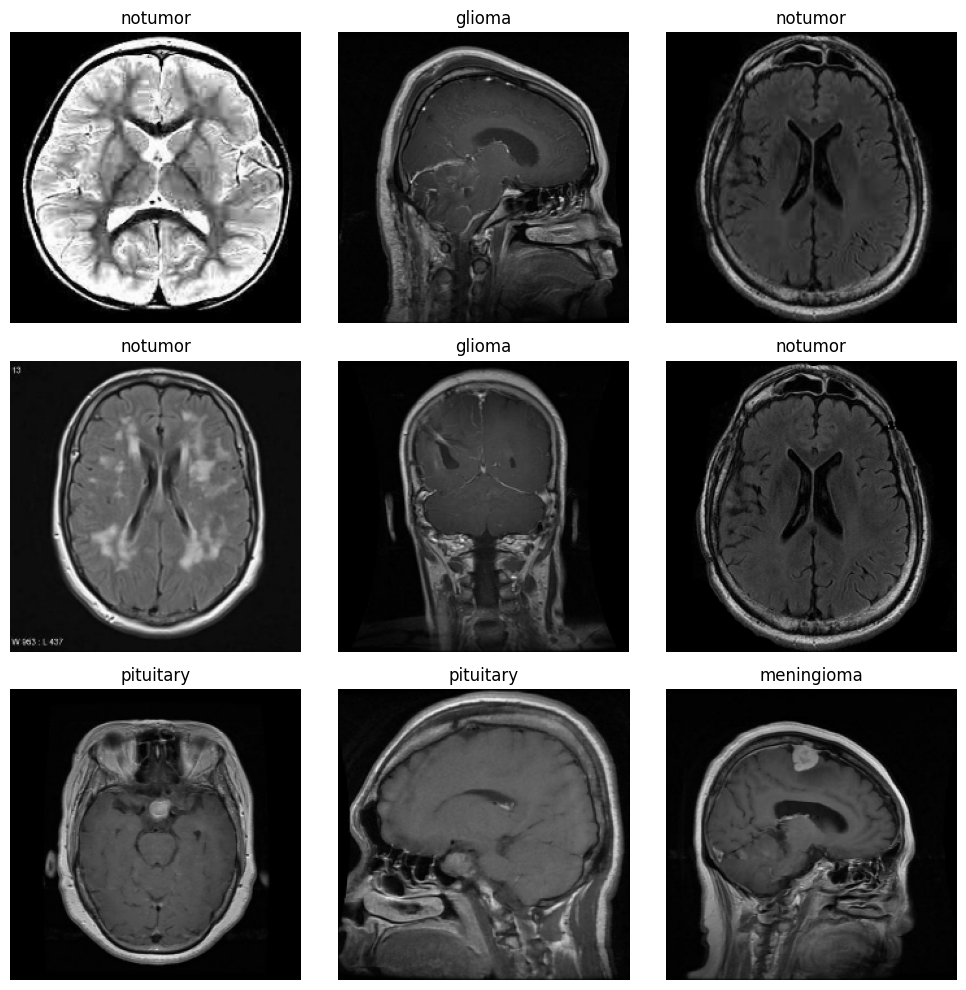

In [7]:
image_batch, label_batch = next(iter(train_generator))

class_names = train_generator.class_names

def plot_images(images, labels, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Displaying the first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
    plt.tight_layout()  # Adjust spacing between plots
    plt.show()

plot_images(image_batch, label_batch, class_names)

In [8]:
# Define the input shape explicitly
input_tensor = Input(shape=(224, 224, 3))

base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)
# Pass the input_tensor to the base model

# Sequential model
resnet50_sequential_model = Sequential()

# Add the base model
resnet50_sequential_model.add(base_model)

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top of the base model
resnet50_sequential_model.add(GlobalAveragePooling2D())
resnet50_sequential_model.add(Dropout(0.5))  # Dropout for regularization
resnet50_sequential_model.add(Dense(1024, activation='relu'))
resnet50_sequential_model.add(Dropout(0.5))
resnet50_sequential_model.add(Dense(4, activation='softmax'))

In [23]:
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
# Load ResNet50 model without the top layer
resnet = ResNet50(include_top=False, input_shape=(224, 224, 3))
resnet.trainable = False  # Freeze the layers

# Add custom layers for binary classification
x = resnet.output
x = GlobalAveragePooling2D()(x)  # Add global average pooling
x = Dense(4, activation='softmax')(x)  # Add a dense layer with sigmoid activation for binary classification

# Create the final model
model = Model(inputs=resnet.input, outputs=x)

# Print the model summary
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
resnet50_history = model.fit(
    train_generator,
    epochs=2,
    validation_data=val_generator,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Epoch 1/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 171s 940ms/step - accuracy: 0.5034 - loss: 1.1322 - val_accuracy: 0.7684 - val_loss: 0.6584
Epoch 2/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 172s 963ms/step - accuracy: 0.8109 - loss: 0.5630 - val_accuracy: 0.8295 - val_loss: 0.5156


In [27]:
model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 891ms/step - accuracy: 0.8153 - loss: 0.5466


[0.5156096816062927, 0.8295165300369263]

In [29]:
class_names = test_generator.class_names

true_labels = []
test_images = []
for images, labels in test_generator:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    test_images.extend(images.numpy())

true_labels = np.array(true_labels)
test_images = np.array(test_images)


pred_probabilities = model.predict(test_images)
pred_labels = np.argmax(pred_probabilities, axis=1)

class_result = classification_report(true_labels, pred_labels, target_names=class_names)
print(class_result)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 999ms/step
              precision    recall  f1-score   support

      glioma       0.95      0.79      0.86        87
  meningioma       0.65      0.55      0.59        80
     notumor       0.86      0.94      0.90       130
   pituitary       0.83      0.95      0.88        96

    accuracy                           0.83       393
   macro avg       0.82      0.81      0.81       393
weighted avg       0.83      0.83      0.82       393



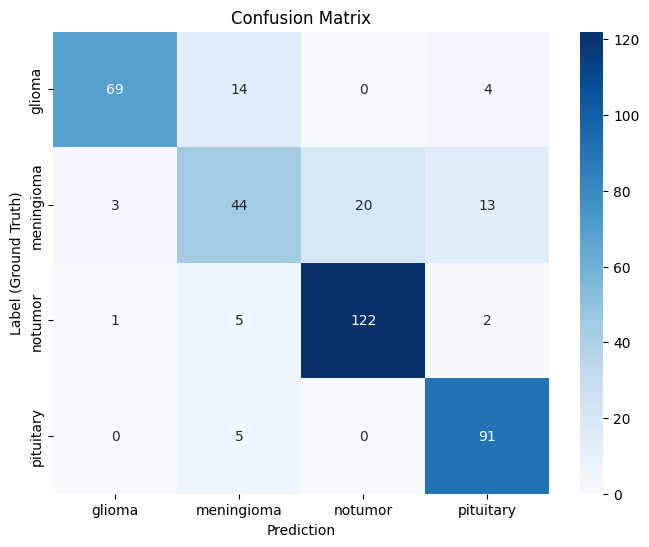

In [30]:
conf_marix = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_marix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Label (Ground Truth)')
plt.title('Confusion Matrix')
plt.show()

In [31]:
model.save("artefacts/_model.h5")  # Save as .h5 file

In [32]:
# Grad-CAM Implementation
def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    casted_grads = tf.cast(grads > 0, "float32") * grads
    pooled_grads = tf.reduce_mean(casted_grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs.numpy()[0]
    pooled_grads = pooled_grads.numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap

In [33]:
import cv2
# Test with a sample image
def overlay_heatmap(heatmap, image, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    output = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)
    return output

In [34]:
# merging it all together
def grad_cam_overlay(model, image, layer_name, alpha=0.4):
    # Expand dimensions to match the model input
    img_array = np.expand_dims(image, axis=0)
    
    # Generate the heatmap
    heatmap = grad_cam(model, img_array, layer_name)
    
    # Overlay the heatmap on the original image
    overlayed_image = overlay_heatmap(heatmap, image, alpha)
    
    return overlayed_image
# Test with a sample image
sample_image = test_images[0]
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB


In [35]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array, np.array(img)  # Return original image for overlay


In [40]:
# Path to the image you want to test
img_path = '/Users/admin/Documents/GitHub/Brain_Tumor_Classification/Data/Testing/pituitary/Te-pi_0011.jpg'

# Preprocess the image
img_array, original_img = load_and_preprocess_image(img_path)

# Generate Grad-CAM heatmap
heatmap = grad_cam(model, img_array, 'conv5_block3_out')


/Users/admin/Documents/GitHub/Brain_Tumor_Classification/venv/lib/python3.12/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_373']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


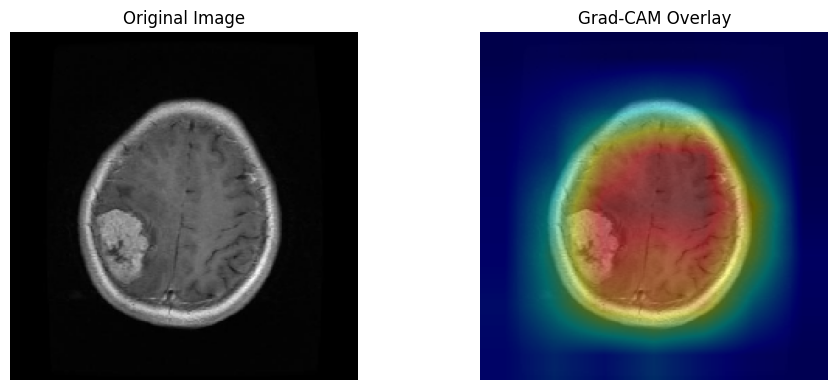

In [38]:
# Convert original image (PIL) to OpenCV format (BGR)
original_img = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)

# Overlay the heatmap
overlayed_img = overlay_heatmap(heatmap, original_img)

# Display the result
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(overlayed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()


In [39]:
preds = model.predict(img_array)
predicted_class = np.argmax(preds)
print(f"Predicted class index: {predicted_class}")
print(f"Prediction probabilities: {preds}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Predicted class index: 1
Prediction probabilities: [[0.06093754 0.453203   0.16598088 0.31987864]]


In [ ]:
class_names = [ 'glioma', 'meningioma', 'no tumor', 'pituitary tumor']